# Advanced Exploratory Data Analysis & Feature Engineering
This notebook covers loading, comprehensive feature engineering, and advanced visualizations for the `online_retail.csv` dataset.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv(r'C:\Users\akash\OneDrive\Desktop\Internship codes\Future_Intern\FUTURE_DS_01\data\online_retail.csv', encoding='unicode_escape')
display(df.head())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Initial Feature Engineering
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayName'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour
df['AvgOrderValue'] = df.groupby('InvoiceNo')['Revenue'].transform('mean')
df['TotalOrderValue'] = df.groupby('InvoiceNo')['Revenue'].transform('sum')
df['Cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')
df['IsReturn'] = df['Quantity'] < 0
df['EstimatedProfit'] = df['Revenue'] * 0.2  # assume 20% margin

In [5]:
# Dropping columns as specified
df.drop(columns=['CustomerID', 'Description'], inplace=True)

## 1. Temporal Analysis: Monthly Revenue & Profit Trends

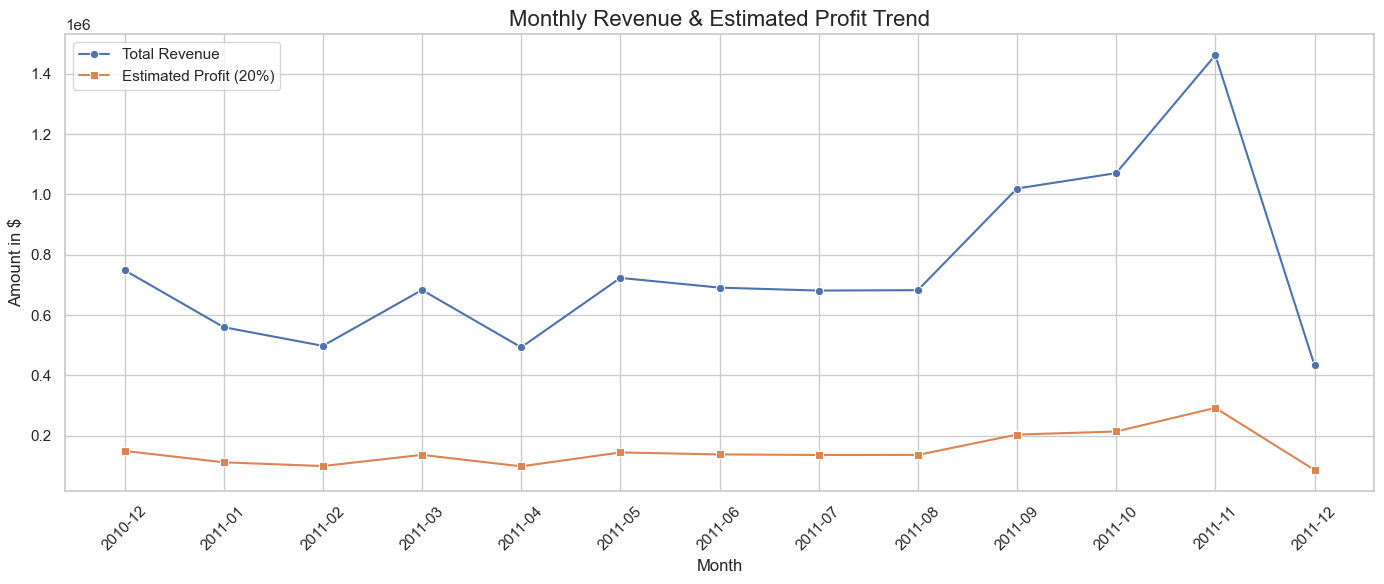

In [6]:
# Convert to Year-Month period for plotting
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly_data = df.groupby('YearMonth')[['Revenue', 'EstimatedProfit']].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_data, x='YearMonth', y='Revenue', marker='o', label='Total Revenue')
sns.lineplot(data=monthly_data, x='YearMonth', y='EstimatedProfit', marker='s', label='Estimated Profit (20%)')
plt.title('Monthly Revenue & Estimated Profit Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount in $', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 2. Advanced Shopping Patterns: Day & Hour Heatmap
Visualizing peak transaction times using a heatmap of total Revenue. This gives much deeper insight than a single bar chart.

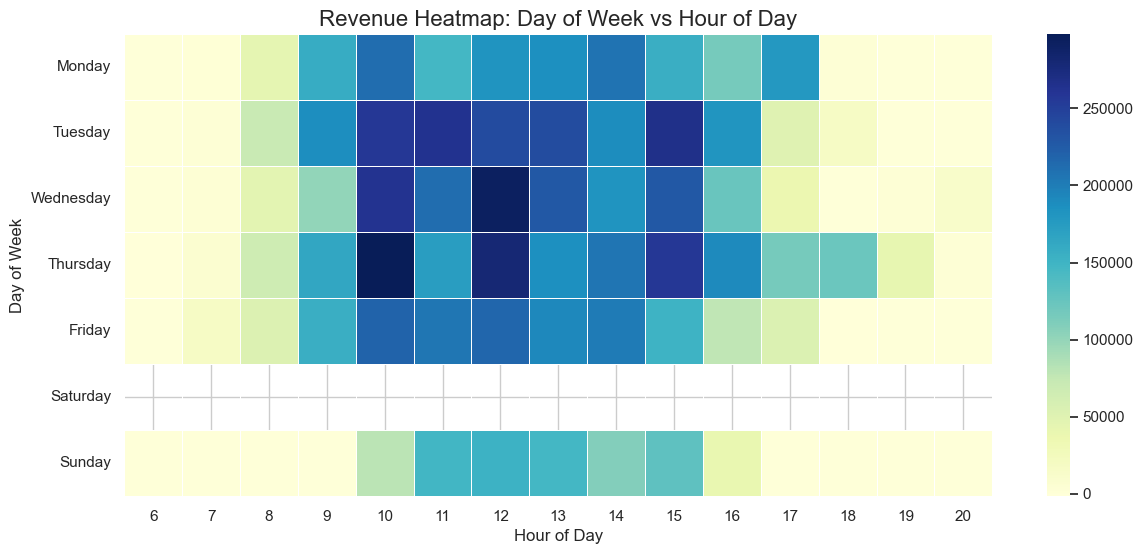

In [7]:
pivot_data = df.pivot_table(index='DayName', columns='Hour', values='Revenue', aggfunc='sum', fill_value=0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_data = pivot_data.reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_data, cmap='YlGnBu', annot=False, linewidths=.5)
plt.title('Revenue Heatmap: Day of Week vs Hour of Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.show()


## 3. Order Value Distribution
Analyzing the distribution of Average Order Value and Total Order Value per Invoice to uncover purchasing habits.

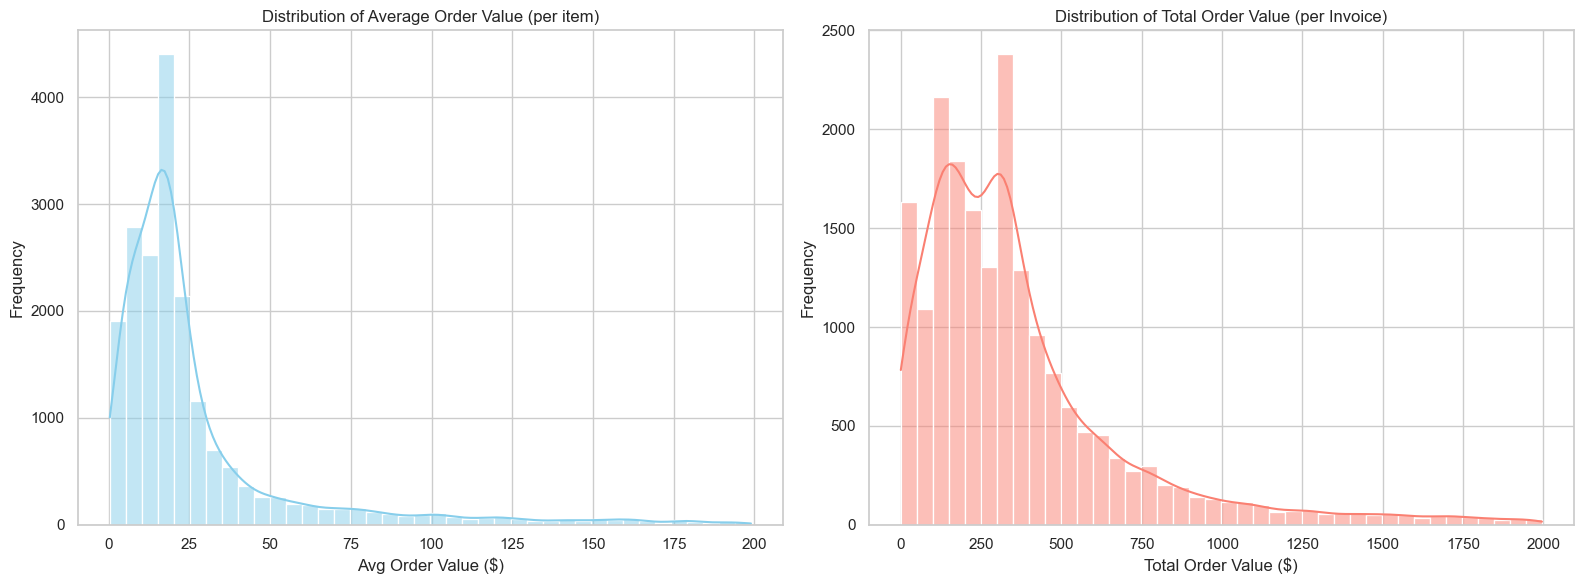

In [8]:
# Extract one record per invoice to analyze order shapes
invoice_summary = df.drop_duplicates('InvoiceNo')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Order Value
sns.histplot(invoice_summary[(invoice_summary['AvgOrderValue'] > 0) & (invoice_summary['AvgOrderValue'] < 200)]['AvgOrderValue'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Average Order Value (per item)')
axes[0].set_xlabel('Avg Order Value ($)')
axes[0].set_ylabel('Frequency')

# Plot 2: Total Order Value
sns.histplot(invoice_summary[(invoice_summary['TotalOrderValue'] > 0) & (invoice_summary['TotalOrderValue'] < 2000)]['TotalOrderValue'], bins=40, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Total Order Value (per Invoice)')
axes[1].set_xlabel('Total Order Value ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 4. Cancellation & Returns Impact
Analyzing absolute losses due to returns & cancellations relative to valid revenue.

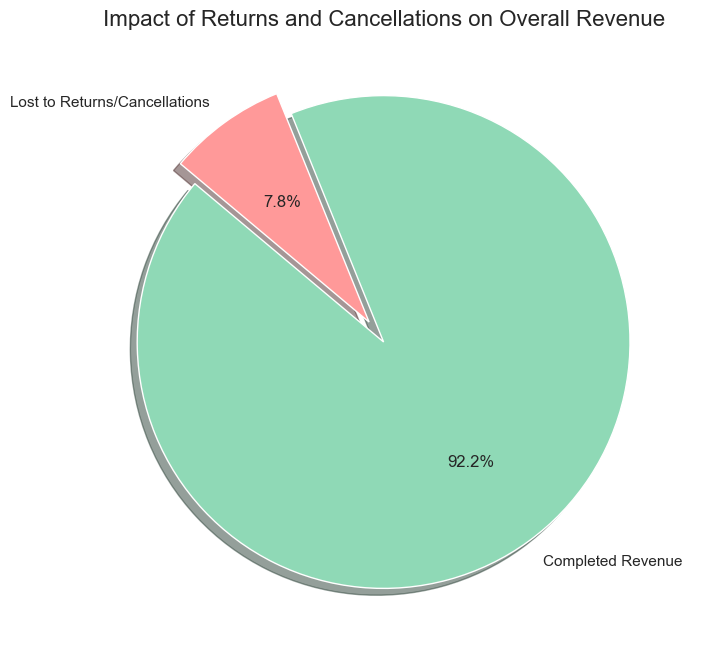

In [9]:
# We isolate positive revenue vs negative revenue
revenue_lost = df[df['IsReturn'] | df['Cancelled']]['Revenue'].sum() * -1
revenue_gained = df[~(df['IsReturn'] | df['Cancelled'])]['Revenue'].sum()

sizes = [revenue_gained, revenue_lost]
labels = ['Completed Revenue', 'Lost to Returns/Cancellations']
colors = ['#8fd9b6', '#ff9999']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, explode=(0, 0.1), shadow=True)
plt.title('Impact of Returns and Cancellations on Overall Revenue', fontsize=16)
plt.show()


## 5. Top 10 Countries by Estimated Profit
Identifying the most lucrative regions based on the 20% estimated margin feature.

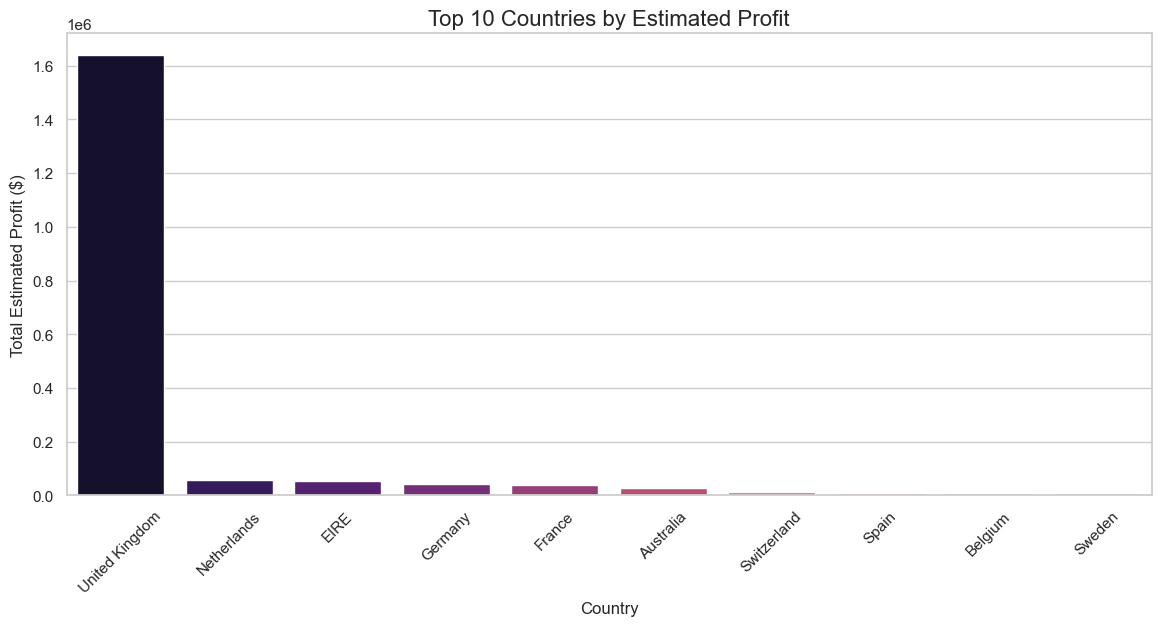

In [10]:
country_profit = df.groupby('Country')['EstimatedProfit'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=country_profit, x='Country', y='EstimatedProfit', palette='magma')
plt.title('Top 10 Countries by Estimated Profit', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Estimated Profit ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()
